#  MNIST Dataset(CNN)

This notebook demonstrates how to use the **Sorix** library to build and train a Convolutional Neural Network (CNN) for digit classification. The syntax is designed to be highly compatible with PyTorch.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mitchell-Mirano/sorix/blob/develop/docs/examples/nn/5-mnist-cnn.ipynb)
[![Open in GitHub](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/Mitchell-Mirano/sorix/blob/develop/docs/examples/nn/5-mnist-cnn.ipynb)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sorix as sx
import sorix.nn as nn
import sorix.optim as optim
from sorix.model_selection import train_test_split
from sorix.utils.data import Dataset, DataLoader
from sorix.metrics import confusion_matrix, classification_report

In [14]:
device = 'cuda' if sx.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

✅ GPU basic operation passed
✅ GPU available: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA runtime version: 13000
CuPy version: 13.6.0
Using device: cuda


## Data Preparation

In [15]:
data = pd.read_csv("../data/digit-recognizer/train.csv")
data_train, data_test = train_test_split(data, test_size=0.2)

def transform(x):
    return (x / 255.0).reshape(1, 28, 28)

train_loader = DataLoader(
    Dataset(data_train.drop("label", axis=1).values, data_train[["label"]].values, transform=transform), 
    batch_size=64, 
    shuffle=True
)

test_loader = DataLoader(
    Dataset(data_test.drop("label", axis=1).values, data_test[["label"]].values, transform=transform), 
    batch_size=64
)

## CNN Architecture

We use `nn.Module` and standard layers just like in PyTorch.

In [16]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.shape[0], -1)  # Using .view() like PyTorch
        x = self.classifier(x)
        return x

model = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

MNIST_CNN(
  (conv_block): Sequential(
    (0): Conv2d()
    (1): ReLU()
    (2): MaxPool2d()
    (3): Conv2d()
    (4): ReLU()
    (5): MaxPool2d()
  )
  (classifier): Sequential(
    (0): Linear(in_features=1568, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Training Loop

In [17]:
epochs = 5
for epoch in range(1, epochs + 1):
    model.train()
    train_loss, train_correct = 0, 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * data.shape[0]
        pred = sx.argmax(output, dim=1, keepdim=True) # Using dim and keepdim aliases
        train_correct += (pred == target).sum().item()
        
    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    with sx.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += criterion(output, target).item() * data.shape[0]
            pred = sx.argmax(output, dim=1, keepdim=True)
            val_correct += (pred == target).sum().item()
            
    print(f"Epoch: {epoch} | Train Acc: {100*train_correct/len(data_train):.2f}% | Val Acc: {100*val_correct/len(data_test):.2f}%")

Epoch: 1 | Train Acc: 92.06% | Val Acc: 97.69%
Epoch: 2 | Train Acc: 97.57% | Val Acc: 98.17%
Epoch: 3 | Train Acc: 98.30% | Val Acc: 98.65%
Epoch: 4 | Train Acc: 98.70% | Val Acc: 98.52%
Epoch: 5 | Train Acc: 98.90% | Val Acc: 98.57%


## Final Metrics

In [18]:
all_preds, all_targets = [], []
model.eval()
with sx.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        output = model(data)
        all_preds.extend(sx.argmax(output, dim=1).cpu().data.flatten())
        all_targets.extend(target.data.flatten())

print(classification_report(all_targets, all_preds))

            precision   recall f1-score  support
0                0.99     0.99     0.99      798
1                0.99     1.00     0.99      920
2                0.98     0.99     0.98      797
3                1.00     0.98     0.99      858
4                0.98     0.99     0.99      813
5                0.97     0.99     0.98      772
6                0.99     0.99     0.99      849
7                0.99     0.99     0.99      929
8                0.98     0.99     0.98      810
9                0.99     0.96     0.97      854

accuracy                           0.99     8400
macro avg        0.99     0.99     0.99     8400
weighted avg     0.99     0.99     0.99     8400


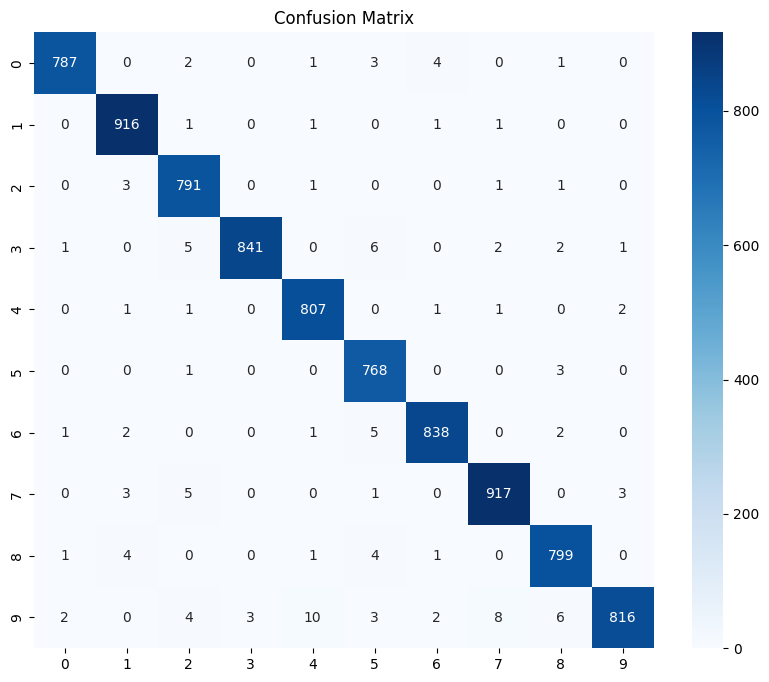

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(all_targets, all_preds), annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.show()